Logistic Regression.

sigmoid function: g(z) = 1/(1+e^-z)

f_wb = g(w.x+b) = 1/(1+e^-(w.x+b))

decision boundary.

cost / simplified cost func for logistic: J_wb = (1/m) * summ (-y_i*np.log(f_wb_i)-(1-y_i)*(np.log(1-f_wb_i)))

gradient descent


In [3]:
import math,copy
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

In [ ]:
input_z = np.arange(-10,11)

def sigmoid(z):
    z = np.clip(z, -500, 500)
    g = 1.0/(1.0 + np.exp(-z))
    return g 


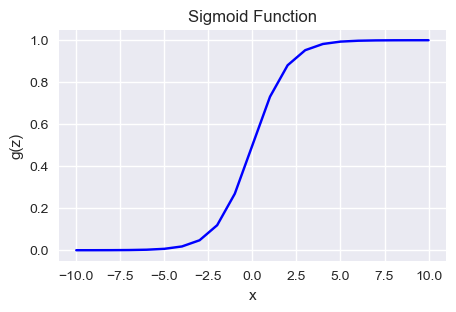

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(5,3))
ax.plot(input_z, sigmoid(input_z),c="b")
ax.set_title("Sigmoid Function")
ax.set_xlabel("x")
ax.set_ylabel("g(z)")
plt.show()

In [ ]:
def J_wb(x,y,w,b):
    m = x.shape[0]
    cost = 0
    for i in range(m):
        f_wb_i = np.dot(w,x[i]) + b
        cost += (f_wb_i - y[i])**2
    return cost/(2*m)

def gradient(x,y,w,b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        f_wb_i = np.dot(w,x[i])+b
        err = f_wb_i - y[i]
 
        dj_dw += err*x[i]
        dj_db += err 
    dj_dw = dj_dw/m 
    dj_db = dj_db/m 
    return dj_dw,dj_db 

def gradient_descent(x,y,w_in,b_in,alpha,iterations,cost_fun,gradient_func):
    w = w_in 
    b = b_in
    J_hist = []
    for i in range(iterations):
        dj_dw,dj_db = gradient_func(x,y,w,b)

        J_hist.append(cost_fun(x,y,w,b))
        if i%math.ceil(iterations/10)==0:
            print(f"J_hist {i}: {J_hist[-1]}")

        w = w - alpha*dj_dw 
        b = b - alpha*dj_db 
    return w,b 


In [ ]:
x_train = np.array([1,2,3,4,5])
y_train = np.array([0,0,0,1,1])
w,b = gradient_descent(x_train,y_train,w_in=0,b_in=0,alpha=0.01,iterations=10000,cost_fun=J_wb,gradient_func=gradient)
print(f"w: {w}, b: {b}")
z = np.dot(w,x_train) + b 


J_hist 0: 0.2
J_hist 1000: 0.03090527540462524
J_hist 2000: 0.030030704712913824
J_hist 3000: 0.030001041428266245
J_hist 4000: 0.030000035322682767
J_hist 5000: 0.030000001198058422
J_hist 6000: 0.03000000004063519
J_hist 7000: 0.030000000001378247
J_hist 8000: 0.03000000000004674
J_hist 9000: 0.03000000000000158
w: 0.2999999932669343, b: -0.4999999756914964


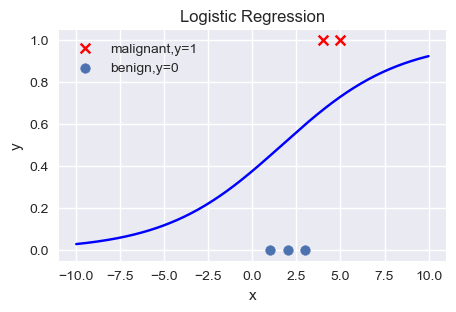

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(5,3))
pos = y_train==1
neg = y_train==0

ax.scatter(x_train[pos],y_train[pos],marker="x",c="r",label="malignant,y=1")
ax.scatter(x_train[neg],y_train[neg],marker="o",label="benign,y=0")

x_range = np.linspace(-10,10,200)
z = w*x_range + b
ax.plot(x_range,sigmoid(z), c="b")
ax.set_title("Logistic Regression")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
plt.show()

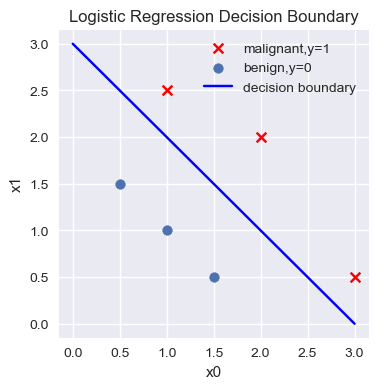

In [ ]:
# decision boundary
X = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y = np.array([0,0,0,1,1,1]).ravel()
pos = y==1
neg = y==0
fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.scatter(X[pos,0],X[pos,1],marker="x",c="r",label="malignant,y=1")
ax.scatter(X[neg,0],X[neg,1],marker="o",label="benign,y=0")
w = np.array([1,1])
b = -3
x0 = np.linspace(0,3,100)
x1 = -(w[0]*x0 + b)/w[1]
ax.plot(x0,x1,c="b",label="decision boundary")
ax.set_title("Logistic Regression Decision Boundary")
ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.legend()
plt.show()

In [ ]:
# simplified cost func
def cost_func_logistic(X,y,w,b):
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        z_i = np.dot(X[i],w) + b
        f_wb_i = sigmoid(z_i)
        cost += -y[i]*np.log(f_wb_i) - (1-y[i])*np.log(1-f_wb_i)
    return cost/m

In [ ]:
w_tmp = np.array([1,1])
b_tmp = -3
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0,0,0,1,1,1])

print(cost_func_logistic(X_train,y_train,w_tmp,b_tmp))

0.36686678640551745


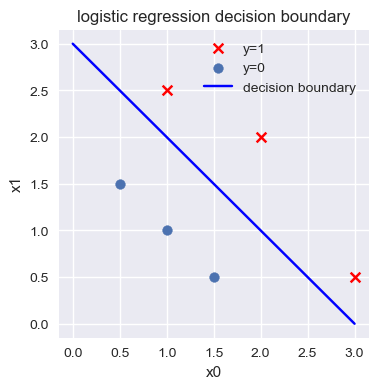

In [20]:
fig,ax = plt.subplots(1,1,figsize=(4,4))
pos = y==1
neg = y==0
ax.scatter(X[pos,0],X[pos,1],marker="x",c="r",label="y=1")
ax.scatter(X[neg,0],X[neg,1],marker="o",label="y=0")

w = np.array([1,1])
b = -3
x0 = np.arange(0,4)
x1 = 3-x0 
ax.plot(x0,x1,c="b",label="decision boundary") 
ax.set_title("logistic regression decision boundary")
ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.legend()
plt.show()

Logistic regression: model, simplified cost func, gradient descent, decision boundary

In [2]:

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0/(1.0 + np.exp(-z))

def cost_func_logistic(X,y,w,b):
    m = X.shape[0]
    cost = 0.0
    for i in range(m):
        z_i = np.dot(X[i],w) + b 
        f_wb_i = sigmoid(z_i)
        cost += -y[i]*np.log(f_wb_i) - (1-y[i])*np.log(1-f_wb_i)
    return cost/m 

def gradient_logistic(X,y,w,b):
    m,n = X.shape
    dj_dw = np.zeros(n)
    dj_db = 0.0
    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i],w) + b)
        err = f_wb_i - y[i]
        for j in range(n):
            dj_dw[j] += err*X[i,j]
        dj_db += err 
    return dj_dw/m, dj_db/m 

def gradient_descent(X,y,w_in,b_in,alpha,iterations,cost_func,gradient_func):
    w = copy.deepcopy(w_in)
    b = b_in 
    J_hist = []
    for i in range(iterations):
        dj_dw, dj_db = gradient_func(X,y,w,b)

        w -= alpha*dj_dw 
        b -= alpha*dj_db
        if i<100000:
            J_hist.append(cost_func(X,y,w,b))
        
        if i%math.ceil(iterations/10)==0:
            print(f"Iterations: {i}, cost: {J_hist[-1]}")
    return w, b, J_hist


In [4]:
X_train = np.array([[0.5, 1.5], [1,1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y_train = np.array([0,0,0,1,1,1])
w_in = np.zeros_like(X_train[0])
b_in = 0.0
alpha = 0.1
iterations = 10000
w_opt, b_opt, J_hist = gradient_descent(X_train,y_train,w_in,b_in,alpha,iterations,cost_func_logistic,gradient_logistic)
print(f"W optimal: {w_opt}, b optimal: {b_opt}")


Iterations: 0, cost: 0.684610468560574
Iterations: 1000, cost: 0.1590977666870457
Iterations: 2000, cost: 0.08460064176930078
Iterations: 3000, cost: 0.05705327279402531
Iterations: 4000, cost: 0.04290759421682
Iterations: 5000, cost: 0.03433847729884557
Iterations: 6000, cost: 0.02860379802212006
Iterations: 7000, cost: 0.02450156960879306
Iterations: 8000, cost: 0.02142370332569295
Iterations: 9000, cost: 0.019030137124109114
W optimal: [5.28123029 5.07815608], b optimal: -14.222409982019837


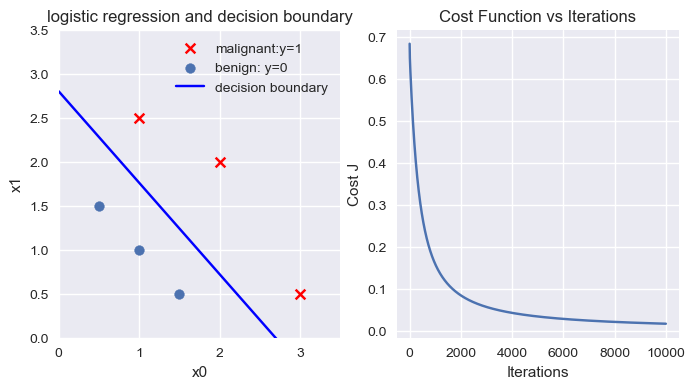

In [16]:
fig,ax = plt.subplots(1,2,figsize=(8,4))
pos = y_train==1
neg = y_train==0
ax[0].scatter(X_train[pos,0],X_train[pos,1],marker="x",c="r",label="malignant:y=1")
ax[0].scatter(X_train[neg,0],X_train[neg,1],marker="o",label="benign: y=0")
ax[0].axis([0,3.5,0,3.5])
x0 = np.arange(0,5)
x1 = -(w_opt[0]*x0 + b_opt)/w_opt[1]
ax[0].plot(x0,x1,c="b",label="decision boundary")
ax[0].set_title("logistic regression and decision boundary")
ax[0].set_xlabel("x0")
ax[0].set_ylabel("x1")
ax[0].legend()

ax[1].plot(J_hist)
ax[1].set_title("Cost Function vs Iterations")
ax[1].set_xlabel("Iterations")
ax[1].set_ylabel("Cost J")
plt.show()

The problem of overfitting fixing by regularization: reduce the parameters


In [ ]:
def regu_cost_func_linear_reg(X,y,w,b, lambda_= 1):
    m,n = X.shape
    cost = 0.0
    for i in range(m):
        f_wb_i = np.dot(X[i],w) + b 
        cost += (f_wb_i - y[i])**2
    cost = cost/(2*m)

    reg_cost = 0.0
    for j in range(n):
        reg_cost += w[j]**2
    reg_cost = (lambda_/(2*m))*reg_cost
    total_cost = cost + reg_cost 
    return total_cost 


In [ ]:
np.random.seed(1)
X_tmp = np.random.rand(5,6)
y_tmp = np.array([0,1,0,1,0])
w_tmp = np.random.rand(X_tmp.shape[1]).reshape(-1) - 0.5
b_tmp = 0.5 
lambda_ = 0.7
print(f"Regularized linear reg Cost: {regu_cost_func_linear_reg(X_tmp,y_tmp,w_tmp,b_tmp,lambda_)}")

Regularized Cost: 0.07917239320214275


In [ ]:
def regu_gradient_linear_reg(X,y,w,b,lambda_= 1):
    m,n = X.shape
    dj_dw = np.zeros(n)
    dj_db = 0.0
    for i in range(m):
        f_wb_i = np.dot(X[i],w) + b 
        err = f_wb_i - y[i]
        for j in range(n):
            dj_dw[j] += err*X[i,j]
        dj_db += err
    dj_dw = dj_dw/m 
    dj_db = dj_db/m 

    for j in range(n):
        dj_dw[j] += (lambda_/m)*w[j]
    return dj_dw, dj_db 

In [ ]:
np.random.seed(1)
X_tmp = np.random.rand(5,3)
y_tmp = np.array([0,1,0,1,0])
w_tmp = np.random.rand(X_tmp.shape[1]).reshape(-1)
b_tmp = 0.5 
lambda_ = 0.7
print(f"Regularized Linear reg Gradient dj_dw, dj_db: {regu_gradient_linear_reg(X_tmp,y_tmp,w_tmp,b_tmp,lambda_)}")

Regularized Gradient dj_dw, dj_db: (array([0.29653215, 0.49116796, 0.21645878]), 0.6648774569425727)


In [19]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    g = 1/(1 + np.exp(-z))
    return g

def regu_cost_func_logistic_reg(X,y,w,b,lambda_= 1):
    m,n = X.shape
    cost = 0.0
    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i],w) + b)
        cost += -y[i]*np.log(f_wb_i) - (1-y[i])*np.log(1-f_wb_i)
    cost = cost/m 

    reg_cost = 0.0
    for j in range(n):
        reg_cost += w[j]**2
    reg_cost = (lambda_/(2*m))*reg_cost 
    total_cost = cost+reg_cost 
    return total_cost

In [20]:
np.random.seed(1)
X_tmp = np.random.rand(5,6)
y_tmp = np.array([0,1,0,1,0])
w_tmp = np.random.rand(X_tmp.shape[1]).reshape(-1) - 0.5
b_tmp = 0.5 
lambda_ = 0.7
print(f"Regularized logistic reg Cost: {regu_cost_func_logistic_reg(X_tmp,y_tmp,w_tmp,b_tmp,lambda_)}")

Regularized logistic reg Cost: 0.6850849138741673


In [21]:
def regu_gradient_logistic_reg(X,y,w,b,lambda_= 1):
    m,n = X.shape
    dj_dw = np.zeros(n)
    dj_db = 0.0
    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i],w) + b)
        err = f_wb_i - y[i]
        for j in range(n):
            dj_dw[j] += err*X[i,j]
        dj_db += err
    dj_dw = dj_dw/m 
    dj_db = dj_db/m 

    for j in range(n):
        dj_dw[j] += (lambda_/m)*w[j]
    return dj_dw, dj_db 

In [22]:
np.random.seed(1)
X_tmp = np.random.rand(5,3)
y_tmp = np.array([0,1,0,1,0])
w_tmp = np.random.rand(X_tmp.shape[1]).reshape(-1)
b_tmp = 0.5 
lambda_ = 0.7
print(f"Regularized logistic reg gradient dj_dw, dj_db: {regu_gradient_logistic_reg(X_tmp,y_tmp,w_tmp,b_tmp,lambda_)}")

Regularized logistic reg gradient dj_dw, dj_db: (array([0.17380013, 0.32007508, 0.10776313]), 0.341798994972791)
